In [1]:
#importing the dependencies
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
import warnings
warnings.filterwarnings('ignore')

In [2]:
House_data=pd.read_csv(r"C:\Users\FAITH\Documents\work\AI\data\archive\housing.csv")

In [3]:
House_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
House_data.shape

(20640, 10)

In [5]:
House_data['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [6]:
House_data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [7]:
House_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [8]:
#checking missing values
House_data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [9]:
House_data['total_bedrooms'].unique()

array([ 129., 1106.,  190., ..., 3008., 1857., 1052.])

In [10]:
#theres a difference between empty cell and nan... if cell is empty, Imputer wont work
#Handling the empty cell in total bedrrom that prevents it from having a skew value.....
#we'll have use an imputer (i.e from sklearn.impute import SimpleImputer) to fill the missing values if it is 'NaN' values to fill but it is an empty cell

value='nan'
result=House_data[House_data['total_bedrooms']==value]
print(result)

Empty DataFrame
Columns: [longitude, latitude, housing_median_age, total_rooms, total_bedrooms, population, households, median_income, median_house_value, ocean_proximity]
Index: []


In [11]:
#fill empty cells with fillna()
x=House_data['total_bedrooms'].median()
House_data['total_bedrooms'].fillna(x,inplace=True)

In [12]:
House_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [13]:
House_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [14]:
#for numerical correlation,copy the original data and drop categorical data
numeric_House_data=House_data.copy()

In [15]:
numeric_House_data.drop(['ocean_proximity'],axis=1,inplace=True)

In [16]:
numeric_House_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0


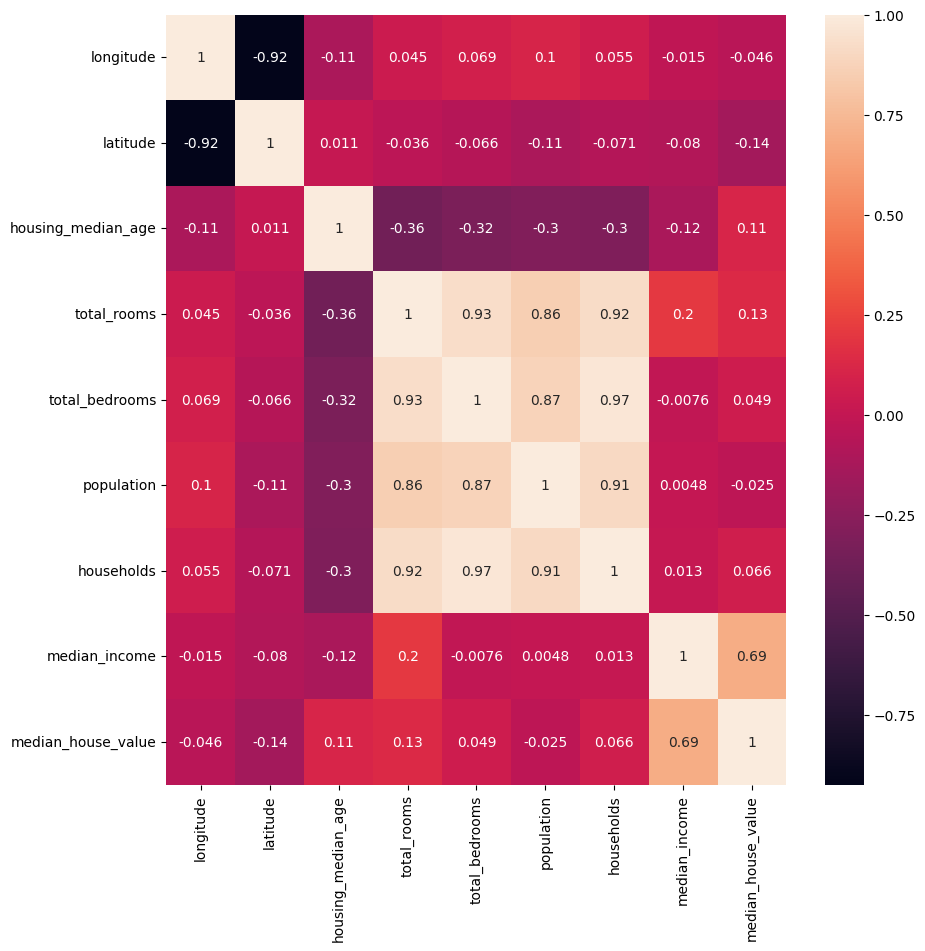

In [17]:
#correlation heatmap

fig, ax=plt.subplots(figsize=(10,10))
sns.heatmap(numeric_House_data.corr(), annot=True)
plt.show()

In [18]:
#Encoding ocean proximity(categorical data)
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
ocean_proximity_encoded = pd.DataFrame(encoder.fit_transform(
    House_data[['ocean_proximity']]).toarray())

updated_House_data = House_data.join(ocean_proximity_encoded)

updated_House_data.rename(columns = {0:'NEAR BAY',1:'1H OCEAN',2:'INLAND',3:'NEAR OCEAN',4:'ISLAND'}, inplace = True)
updated_House_data.reset_index(inplace = True)

In [21]:
updated_House_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,NEAR BAY,1H OCEAN,INLAND,NEAR OCEAN,ISLAND
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0


In [22]:
updated_House_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,NEAR BAY,1H OCEAN,INLAND,NEAR OCEAN,ISLAND
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0


In [23]:
#splitting data into predictants(X) and target(y)
X=updated_House_data.drop(columns='median_house_value',axis=1)
Y=updated_House_data['median_house_value']

In [24]:
#Seperating data into train and test
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [25]:
#get your train data by joining Xtrain with Y train
train_data=X_train.join(Y_train)

In [26]:
#feature engineering i.e- adding descripture features with common characteristics
train_data['bedroom_ratio']=train_data['total_bedrooms']/train_data['total_rooms']
train_data['household_room']=train_data['total_rooms']/train_data['households']

In [27]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,NEAR BAY,1H OCEAN,INLAND,NEAR OCEAN,ISLAND,median_house_value,bedroom_ratio,household_room
14196,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596,NEAR OCEAN,0.0,0.0,0.0,0.0,1.0,103000.0,0.200576,5.017657
8267,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125,NEAR OCEAN,0.0,0.0,0.0,0.0,1.0,382100.0,0.232703,4.473545
17445,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563,NEAR OCEAN,0.0,0.0,0.0,0.0,1.0,172600.0,0.174486,5.645833
14265,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425,NEAR OCEAN,0.0,0.0,0.0,0.0,1.0,93400.0,0.258269,4.002817
2271,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542,INLAND,0.0,1.0,0.0,0.0,0.0,96500.0,0.180940,6.268421
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-117.96,33.78,35.0,1330.0,201.0,658.0,217.0,6.3700,<1H OCEAN,1.0,0.0,0.0,0.0,0.0,229200.0,0.151128,6.129032
11964,-117.43,34.02,33.0,3084.0,570.0,1753.0,449.0,3.0500,INLAND,0.0,1.0,0.0,0.0,0.0,97800.0,0.184825,6.868597
5390,-118.38,34.03,36.0,2101.0,569.0,1756.0,527.0,2.9344,<1H OCEAN,1.0,0.0,0.0,0.0,0.0,222100.0,0.270823,3.986717
860,-121.96,37.58,15.0,3575.0,597.0,1777.0,559.0,5.7192,<1H OCEAN,1.0,0.0,0.0,0.0,0.0,283500.0,0.166993,6.395349


In [28]:
train_data.drop(columns='ocean_proximity',axis=1,inplace=True)

In [29]:
#spllitthe train data back to xtrain and y train
X_train,Y_train=train_data.drop(['median_house_value'],axis=1),train_data['median_house_value']

In [30]:
#Do same or the test data
#get your test data by joining Xtrain with Y train
test_data=X_test.join(Y_test)

In [31]:
#feature engineering i.e- adding descripture features with common characteristics
test_data['bedroom_ratio']=test_data['total_bedrooms']/test_data['total_rooms']
test_data['household_room']=test_data['total_rooms']/test_data['households']

In [32]:
test_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,NEAR BAY,1H OCEAN,INLAND,NEAR OCEAN,ISLAND,median_house_value,bedroom_ratio,household_room
20046,-119.01,36.06,25.0,1505.0,435.0,1392.0,359.0,1.6812,INLAND,0.0,1.0,0.0,0.0,0.0,47700.0,0.289037,4.192201
3024,-119.46,35.14,30.0,2943.0,435.0,1565.0,584.0,2.5313,INLAND,0.0,1.0,0.0,0.0,0.0,45800.0,0.147808,5.039384
15663,-122.44,37.80,52.0,3830.0,435.0,1310.0,963.0,3.4801,NEAR BAY,0.0,0.0,0.0,1.0,0.0,500001.0,0.113577,3.977155
20484,-118.72,34.28,17.0,3051.0,435.0,1705.0,495.0,5.7376,<1H OCEAN,1.0,0.0,0.0,0.0,0.0,218600.0,0.142576,6.163636
9814,-121.93,36.62,34.0,2351.0,435.0,1063.0,428.0,3.7250,NEAR OCEAN,0.0,0.0,0.0,0.0,1.0,278000.0,0.185028,5.492991
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15362,-117.22,33.36,16.0,3165.0,482.0,1351.0,452.0,4.6050,<1H OCEAN,1.0,0.0,0.0,0.0,0.0,263300.0,0.152291,7.002212
16623,-120.83,35.36,28.0,4323.0,886.0,1650.0,705.0,2.7266,NEAR OCEAN,0.0,0.0,0.0,0.0,1.0,266800.0,0.204950,6.131915
18086,-122.05,37.31,25.0,4111.0,538.0,1585.0,568.0,9.2298,<1H OCEAN,1.0,0.0,0.0,0.0,0.0,500001.0,0.130868,7.237676
2144,-119.76,36.77,36.0,2507.0,466.0,1227.0,474.0,2.7850,INLAND,0.0,1.0,0.0,0.0,0.0,72300.0,0.185880,5.289030


In [33]:
test_data.drop(columns='ocean_proximity',axis=1,inplace=True)

In [34]:
#spllitthe test data back to xtest and y test
X_test,Y_test=test_data.drop(['median_house_value'],axis=1),test_data['median_house_value']

In [35]:
#The result is processed and thereby scaling the inputs
#we reprocess and thereby scaling the inputs
from sklearn.preprocessing import MinMaxScaler

In [36]:
scaler=MinMaxScaler()

In [37]:
X_train_s=scaler.fit_transform(X_train)

In [38]:
X_test_s=scaler.transform(X_test)

In [39]:
#intializing the regression model
model=LinearRegression()

In [40]:
#Training the Linear Regression with training data
model.fit(X_train,Y_train)

LinearRegression()

In [41]:
model.score(X_test,Y_test)

0.5968421508294981

In [42]:
model.fit(X_train_s,Y_train)

LinearRegression()

In [43]:
#The scaled xtest may perorm better......
model.score(X_test_s,Y_test)

0.596811094226726

In [44]:
#Importing GridsearchCV for best model
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import ShuffleSplit

In [45]:
forest=RandomForestRegressor()

In [46]:
forest.fit(X_train,Y_train)

RandomForestRegressor()

In [47]:
forest.score(X_test,Y_test)

0.8116500874108284

In [48]:
#use the scaled data to see improvements
forest.fit(X_train_s,Y_train)

RandomForestRegressor()

In [49]:
forest.score(X_test_s,Y_test)

0.8103851474059984

In [50]:
#further processing to get the best values use grid search
from sklearn.model_selection import GridSearchCV

In [51]:
forest=RandomForestRegressor()
params_grid={'n_estimators': [3, 10, 30],
             'max_features':[2,4,6,8]}
gridSearch=GridSearchCV(forest,params_grid,cv=10,scoring='neg_mean_squared_error',
                        return_train_score=True)

gridSearch.fit(X_train_s,Y_train)

GridSearchCV(cv=10, estimator=RandomForestRegressor(),
             param_grid={'max_features': [2, 4, 6, 8],
                         'n_estimators': [3, 10, 30]},
             return_train_score=True, scoring='neg_mean_squared_error')

In [52]:
bestForest=gridSearch.best_estimator_

In [53]:
bestForest.score(X_test_s,Y_test)

0.8047778088386082

In [55]:
#we want to use a loop to find best estimators by create a new numeric variable and a function that takes multiple algorithm
#create new variable name
New_X=X.copy()

In [56]:
New_X.drop(columns='ocean_proximity',axis=1,inplace=True)
New_X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,NEAR BAY,1H OCEAN,INLAND,NEAR OCEAN,ISLAND
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,0.0,0.0,0.0,1.0,0.0


In [57]:
#we want to use a loop to find best estimators by create a new numeric variable and a function that takes multiple algorithm
#create new variable name
New_Y=Y.copy()

In [58]:
#Seperating data into train and test
New_X_train,New_X_test,New_Y_train,New_Y_test=train_test_split(New_X,New_Y,test_size=0.2)

In [61]:
#use gridsearch library imported above
#for selecting the best model
def best_model_selection(New_X,New_Y):
    models = {
        'Decision Tree Regression' : {
            'model' : DecisionTreeRegressor(),
            'params' : {
                'max_depth': [None, 5, 10, 15],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4],
                'max_features': ['auto', 'sqrt', 'log2']}
        },
        'Ridge Regression' : {
            'model' : Ridge(),
            'params': {
                'alpha': [0.1, 0.5, 1.0, 10.0]}
        },
        'Lasso Regression' : {
            'model' : Lasso(),
            'params' : {
                'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
            }
        },
        'Random Forest Regressor ' : {
            'model': RandomForestRegressor(),
            'params' : {
                'n_estimators': [10, 20, 30]
            }
        },
        
    }
    scores = []
    cv = ShuffleSplit(n_splits=5, test_size=0.20, random_state=0)
    for model_name, config in models.items():
        gs =  GridSearchCV(config['model'], config['params'], cv=cv, return_train_score=False)
        gs.fit(New_X_train,New_Y_train)
        scores.append({
            'model': model_name,
            'best_score': gs.best_score_,
            'best_params': gs.best_params_
        })
    return pd.DataFrame(scores,columns=['model','best_score','best_params'])

In [62]:
best_model_selection(New_X_train,New_Y_train)

,model,best_score,best_params
0,Decision Tree Regression,0.670448,"{'max_depth': 15, 'max_features': 'log2', 'min..."
1,Ridge Regression,0.632245,{'alpha': 0.1}
2,Lasso Regression,0.632249,{'alpha': 0.001}
3,Random Forest Regressor,0.809809,{'n_estimators': 30}


In [64]:
#intializing the regression model
model=LinearRegression()

In [65]:
forest=RandomForestRegressor()

In [66]:
#Building all the best models
best_linear = LinearRegression().fit(New_X_train, New_Y_train)
best_lasso = Lasso(alpha = 1).fit(New_X_train, New_Y_train)
best_ridge = Ridge(alpha = 10).fit(New_X_train, New_Y_train)
best_tree = DecisionTreeRegressor(max_depth = 15, max_features = 'log2', min_samples_leaf = 4,min_samples_split = 10).fit(New_X_train, New_Y_train)
best_forest = RandomForestRegressor(n_estimators = 30).fit(New_X_train, New_Y_train)

In [67]:
#Y_pred for all the models
y_pred_linear = best_linear.predict(New_X_test)
y_pred_lasso = best_lasso.predict(New_X_test)
y_pred_ridge = best_ridge.predict(New_X_test)
y_pred_tree = best_tree.predict(New_X_test)
y_pred_forest = best_forest.predict(New_X_test)

In [68]:
#Evaluation metrics for regression models
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import r2_score

In [69]:
#Mean Absolute Error
mae_linear = mae(New_Y_test,y_pred_linear)
mae_lasso = mae(New_Y_test,y_pred_lasso)
mae_ridge = mae(New_Y_test,y_pred_ridge)
mae_tree = mae(New_Y_test,y_pred_tree)
mae_forest = mae(New_Y_test,y_pred_forest)

In [70]:
#Mean Squared Error
mse_linear = mse(New_Y_test,y_pred_linear)
mse_lasso = mse(New_Y_test,y_pred_lasso)
mse_ridge = mse(New_Y_test,y_pred_ridge)
mse_dc = mse(New_Y_test,y_pred_tree)
mse_rfr = mse(New_Y_test,y_pred_forest)

In [71]:
#Coefficient of determination
r2_linear = r2_score(New_Y_test,y_pred_linear)
r2_lasso = r2_score(New_Y_test,y_pred_lasso)
r2_ridge = r2_score(New_Y_test,y_pred_ridge)
r2_tree = r2_score(New_Y_test,y_pred_tree)
r2_forest = r2_score(New_Y_test,y_pred_forest)

In [72]:
#--Evaluation Metrics df
eval_result = pd.DataFrame({'MAE':[mae_linear,mae_lasso,mae_ridge,mae_tree,mae_forest], 
                        'MSE':[mse_linear,mse_lasso,mse_ridge,mae_tree,mae_forest],
                       'R2 Score' : [r2_linear,r2_lasso,r2_ridge,mae_tree,mae_forest], 
                    'Model': ['Linear Regression','Lasso Regression','Ridge Regression','Decision Trees','Random Forest']})
eval_result.head()

,MAE,MSE,R2 Score,Model
0,49509.220881,4.657276e+09,0.649190,Linear Regression
1,49509.671222,4.657294e+09,0.649188,Lasso Regression
2,49519.547115,4.657466e+09,0.649175,Ridge Regression
3,44437.396754,4.443740e+04,44437.396754,Decision Trees
4,32108.845518,3.210885e+04,32108.845518,Random Forest


In [72]:
#since the MAE ,and MSE of the Random forest is lowest, it is very good for predicting the model
#The R2 score seems so high probably because of the hypertunning...redefine parameters